# Text Clustering & Topic Modeling

In [1]:
from datasets import load_dataset

In [2]:
ds = load_dataset("TheDima/arxiv-cs-2022-2026")

In [3]:
len(ds['train'])

429126

In [4]:
abstracts = list(ds['train']['summary'])
titles = list(ds['train']['title'])

There are multiple ways to do text clustering. Here, we will be looking at the next one:

1. Convert the input documents into embeddings
2. Reduce dimensionality of embeddings
3. Find groups of semantically similar documents

# The Pipeline

## 1. Embedding Documents

In [5]:
from sentence_transformers import SentenceTransformer

In [6]:
embedding_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B", device='cuda')

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [7]:
abstracts = list(ds['train']['summary'])[:100_000]
titles = list(ds['train']['title'])[:100_000]

In [42]:
# Clean-up to release GPU memory
del(embedding_model)

In [8]:
%%time
embeddings = embedding_model.encode(
    abstracts,
    batch_size=32,
    device=["cuda:0", "cuda:1"],
    show_progress_bar=True,
)

Chunks:   0%|          | 0/20 [00:00<?, ?it/s]

CPU times: user 25.7 s, sys: 804 ms, total: 26.5 s
Wall time: 4min 46s


## 2. Reducing Dimensionality of Embeddings

Before we cluster the embeddings, we need to reduce their dimensionality. Dimensionality reduction techniques aim to preserve the global structure of high-dimensional data by finding low-dimensional representation.

There are linear and non-linear dimensionality reduction techniques.  
PCA is a linear technique for dimensionality reduction, while UMAP is an example of non-linear dimensionality reduction, also known as **Manifold Learning**.

The trick behind the manifold learning is to define "similarity" beyond euclidean distance. We need answer the questions:

- What is my neighbor?
- How many neighbors do I actually have?
- How close are they?
- Do I ignore far neighbors?

There is no one way to answer these questions, in contrast to a single definition, single way to get linear distance - euclidean distance.

In [9]:
from cuml.manifold import UMAP

Cross-entropy measures how well one probability distribution \(Q\) approximates another \(P\):

$$ H(P,Q)=-\sum_i P_i\log Q_i $$

Lower is better.

KL divergence measures the extra information cost of using \(Q\) instead of the true distribution \(P\):

$$ D_{\mathrm{KL}}(P\|Q) =\sum_i P_i\log\frac{P_i}{Q_i} $$

Since

$$ D_{\mathrm{KL}}(P\|Q)=H(P,Q)-H(P), $$

minimizing cross-entropy with respect to \(Q\) is equivalent to minimizing KL divergence because \(H(P)\) is fixed.

UMAP first converts the high-dimensional dataset into a probabilistic weighted graph.

For nearby points \(i,j\), define a high-dimensional similarity roughly as

$$ p_{ij}\approx \exp\left( -\frac{\max(0,d(x_i,x_j)-\rho_i)}{\sigma_i} \right). $$

So:

- $p_{ij}\approx1$: strongly connected neighbors
- $p_{ij}\approx0$: unrelated points.

Then UMAP chooses low-dimensional coordinates $y_i$ and defines a corresponding similarity

$$ q_{ij} = \frac{1}{1+a\|y_i-y_j\|^{2b}}. $$

Now we want the low-dimensional graph \(Q\) to resemble the original graph \(P\).

But each edge is effectively a Bernoulli variable: edge exists with probability $p_{ij}$. Therefore the appropriate cross-entropy is

$$ \boxed{ L = -\sum_{i,j} \left[ p_{ij}\log q_{ij} + (1-p_{ij})\log(1-q_{ij}) \right] } $$

or, equivalently up to constants, a KL-like divergence between the two fuzzy graphs.

The two terms explain UMAP intuitively:

$$ -\underbrace{p_{ij}\log q_{ij}}_{\text{attraction}} - \underbrace{(1-p_{ij})\log(1-q_{ij})}_{\text{repulsion}}. $$

Neighbors with high $p_{ij}$ are pulled together; non-neighbors are pushed apart.

So the concise derivation is:

$$ \boxed{ \text{distances} \rightarrow \text{neighbor probabilities }P \rightarrow \text{low-D probabilities }Q \rightarrow \text{minimize cross-entropy}(P,Q) } $$

In [10]:
umap_model = UMAP(
    n_components=5, # generally, values between 5 and 10 work well to capture high-dimensional structures.
    metric="cosine",
    random_state=42,
)

In [11]:
%%time
reduced_embeddings = umap_model.fit_transform(embeddings)

CPU times: user 1.36 s, sys: 121 ms, total: 1.48 s
Wall time: 1.45 s


In [12]:
reduced_embeddings

array([[-1.8814148e+00,  2.4891145e+00,  4.4659954e-01, -1.7399971e-01,
         3.8301980e-01],
       [-1.4247155e+00, -2.5837612e+00,  7.3449337e-01, -1.6630737e+00,
        -6.5951884e-01],
       [-2.5203092e+00,  2.1422837e+00, -3.6212561e-01,  2.4555637e-01,
        -1.9807333e+00],
       ...,
       [-3.0036092e+00, -2.0961846e-01,  9.8823354e-02,  7.9174393e-01,
        -3.8969558e-01],
       [-1.1500365e+00,  8.5040271e-01, -3.4275186e-01,  9.5539337e-01,
        -9.8541984e-04],
       [ 1.2583332e+00,  1.6047631e-01, -2.0941150e+00, -1.0706716e+00,
         8.1264710e-01]], shape=(100000, 5), dtype=float32)

## 3. Cluster the Embeddings

We can use **centroid-based algorithm** like k-means, which requires a set of clusters to be generated, but we do not know the number of clusters beforehand. Instead, a **density-based algorithms** freely calculate the number of clusters and does not force all data points to be a part of a cluster, which even helps finding outliers. 

In [13]:
from cuml.cluster.hdbscan import HDBSCAN

In [14]:
%%time
# metric (default=’euclidean’), cluster_selection_method (default=’eom’)
hdbscan_model = HDBSCAN(min_cluster_size=50).fit(reduced_embeddings)

CPU times: user 347 ms, sys: 18.9 ms, total: 366 ms
Wall time: 346 ms


In [15]:
clusters = hdbscan_model.labels_

In [16]:
clusters
# -1 means noise / unclustered

array([127,  77,  -1, ...,  46,  -1,  53], shape=(100000,))

In [17]:
unique_clusters = list(int(cluster) for cluster in set(clusters))

In [18]:
unique_clusters[:20]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

Let's explore a cluster!

In [19]:
labels = clusters.tolist()

cluster_21 = [
    {"title": title, "abstract": abstract}
    for title, abstract, label in zip(titles, abstracts, labels)
    if label == 21
]

In [20]:
import pandas as pd

cluster_21 = pd.DataFrame({
    "title": titles,
    "abstract": abstracts,
    "cluster": labels,
})

cluster_21 = cluster_21[cluster_21["cluster"] == 21]

In [21]:
for title in cluster_21['title'][:10]:
    print(title)

Adaptive Memory Networks with Self-supervised Learning for Unsupervised Anomaly Detection
Latent Vector Expansion using Autoencoder for Anomaly Detection
Anomalous Sound Detection using Spectral-Temporal Information Fusion
Compressed Smooth Sparse Decomposition
Anomaly Detection via Reverse Distillation from One-Class Embedding
A Survey of Visual Sensory Anomaly Detection
Latent Outlier Exposure for Anomaly Detection with Contaminated Data
ALGAN: Anomaly Detection by Generating Pseudo Anomalous Data via Latent Variables
Do autoencoders need a bottleneck for anomaly detection?
Bayesian autoencoders with uncertainty quantification: Towards trustworthy anomaly detection


Each cluster size:

In [22]:
cluster_sizes = pd.Series(labels).value_counts().sort_index()

In [23]:
cluster_sizes.describe()

count      204.000000
mean       490.196078
std       3272.805884
min         50.000000
25%         75.000000
50%        124.500000
75%        277.250000
max      46617.000000
Name: count, dtype: float64

In [24]:
cluster_sizes.sort_values(ascending=False)

-1      46617
 55      3322
 76      3178
 129     2725
 158     1409
        ...  
 122       52
 68        51
 121       50
 120       50
 173       50
Name: count, Length: 204, dtype: int64

In [25]:
umap_model_3d = UMAP(
    n_components=3,
    metric="cosine",
    random_state=42,
)
reduced_embeddings_3d = umap_model.fit_transform(embeddings)

In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
labels = clusters.get() if hasattr(clusters, "get") else np.asarray(clusters)
X = reduced_embeddings_3d.get() if hasattr(reduced_embeddings_3d, "get") else np.asarray(reduced_embeddings_3d)

In [28]:
# We can show all topics, but it is nice to filter some to see the power of clustering.
selected_clusters = [21, 42, 84, 168, 200]

mask = np.isin(labels, selected_clusters)

X_selected = X[mask]
labels_selected = labels[mask]

In [29]:
rng = np.random.default_rng(42)

n = min(20_000, len(X_selected))
idx = rng.choice(len(X_selected), size=n, replace=False)

X_plot = X_selected[idx]
labels_plot = labels_selected[idx]

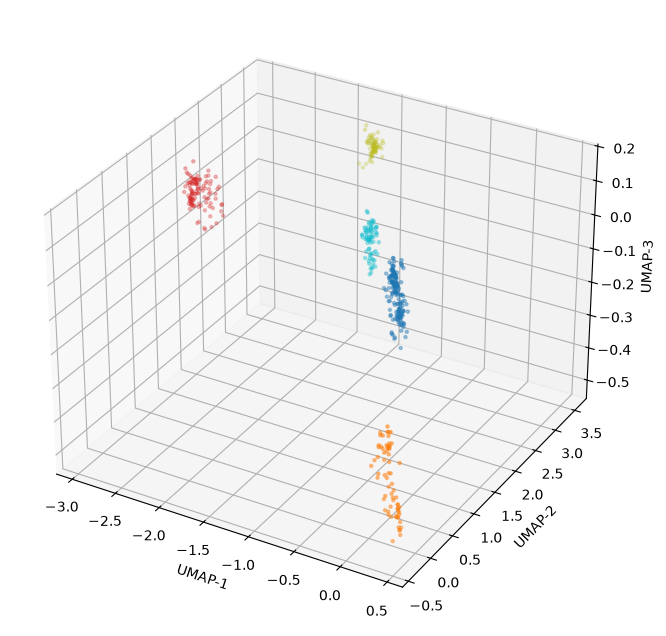

In [30]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_plot[:, 0],
    X_plot[:, 1],
    X_plot[:, 2],
    c=labels_plot,
    s=5,
    alpha=0.7,
    cmap="tab10",
)

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")

plt.show()

# Topic Modeling

So far we don't know what is going on inside the clusters. We can extend our understanding with topic modeling.

In [31]:
from bertopic import BERTopic

I0000 00:00:1789334146.692913   23963 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789334146.715015   23963 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789334147.513765   23963 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789334147.513953   23963 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU

In [32]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2026-09-13 21:15:49,783 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-13 21:15:51,078 - BERTopic - Dimensionality - Completed ✓
2026-09-13 21:15:51,080 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-13 21:15:51,407 - BERTopic - Cluster - Completed ✓
2026-09-13 21:15:51,414 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-13 21:15:55,103 - BERTopic - Representation - Completed ✓


In [33]:
topic_model.get_topic_info()
# Each of the topics is represented by several keywords, concatenated with with "_".

,Topic,Count,Name,Representation,Representative_Docs
0,-1,46617,-1_the_of_and_to,"[the, of, and, to, in, we, for, is, that, on]",[Pretrained language models based on the trans...
1,0,3322,0_speech_audio_speaker_asr,"[speech, audio, speaker, asr, music, acoustic,...","[In recent years, the joint training of speech..."
2,1,3178,1_code_software_ai_explanations,"[code, software, ai, explanations, developers,...",[The shift from symbolic AI systems to black-b...
3,2,2725,2_channel_ris_wireless_communication,"[channel, ris, wireless, communication, mimo, ...",[The various requirements in terms of data rat...
4,3,1409,3_equations_physics_pdes_neural,"[equations, physics, pdes, neural, differentia...",[Physics-informed neural networks (PINNs) have...
...,...,...,...,...,...
199,198,52,198_gnns_gnn_explanation_graph,"[gnns, gnn, explanation, graph, explanations, ...",[Graph Neural Networks (GNNs) are widely adopt...
200,199,51,199_sentiment_aspect_absa_aste,"[sentiment, aspect, absa, aste, opinion, polar...",[Aspect-based sentiment analysis (ABSA) aims a...
201,200,50,200_opinion_opinions_social_agents,"[opinion, opinions, social, agents, formation,...",[Opinion spreading in a society decides the fa...
202,201,50,201_dg_domain_generalization_domains,"[dg, domain, generalization, domains, invarian...",[Domain generalization (DG) focuses on transfe...


In [34]:
# Learning about individual topic
topic_model.get_topic(21)

[('networks', np.float64(0.018416126042533596)),
 ('neural', np.float64(0.017341222120964797)),
 ('relu', np.float64(0.014595148975824916)),
 ('activation', np.float64(0.012501049640257118)),
 ('descent', np.float64(0.012137044366693644)),
 ('gradient', np.float64(0.011210903996518147)),
 ('width', np.float64(0.011046518414350571)),
 ('generalization', np.float64(0.01007059636100794)),
 ('functions', np.float64(0.009946605524372225)),
 ('layer', np.float64(0.009263314068621138))]

In [35]:
# finding a specific topic
topic_model.find_topics("voice recognition")

([0, 30, 163, -1, 137],
 [np.float32(0.64434576),
  np.float32(0.5609758),
  np.float32(0.5431195),
  np.float32(0.516253),
  np.float32(0.5153012)])

In [36]:
topic_model.get_topic(0)

[('speech', np.float64(0.029895900004767693)),
 ('audio', np.float64(0.017731656880689218)),
 ('speaker', np.float64(0.014685095055034429)),
 ('asr', np.float64(0.012156115250535657)),
 ('music', np.float64(0.008774400022899318)),
 ('acoustic', np.float64(0.007499084630311095)),
 ('recognition', np.float64(0.007310575964046713)),
 ('voice', np.float64(0.007222043287518401)),
 ('sound', np.float64(0.006115845487820942)),
 ('tts', np.float64(0.005769959093160855))]

In [37]:
# We can also index any specific string to find out its topic
topic_index = topic_model.topics_[titles.index("Do autoencoders need a bottleneck for anomaly detection?")]
topic_model.get_topic(topic_index)

[('anomaly', np.float64(0.06899421816642326)),
 ('detection', np.float64(0.0265881814708868)),
 ('anomalies', np.float64(0.026082274867567718)),
 ('normal', np.float64(0.023507870127477914)),
 ('anomalous', np.float64(0.017339032692175717)),
 ('ad', np.float64(0.016044835833737878)),
 ('mvtec', np.float64(0.014125858450351357)),
 ('unsupervised', np.float64(0.011445817793323553)),
 ('industrial', np.float64(0.009148572183755371)),
 ('abnormal', np.float64(0.008072125759408287))]

In [38]:
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1600,
    hide_annotations=True
)

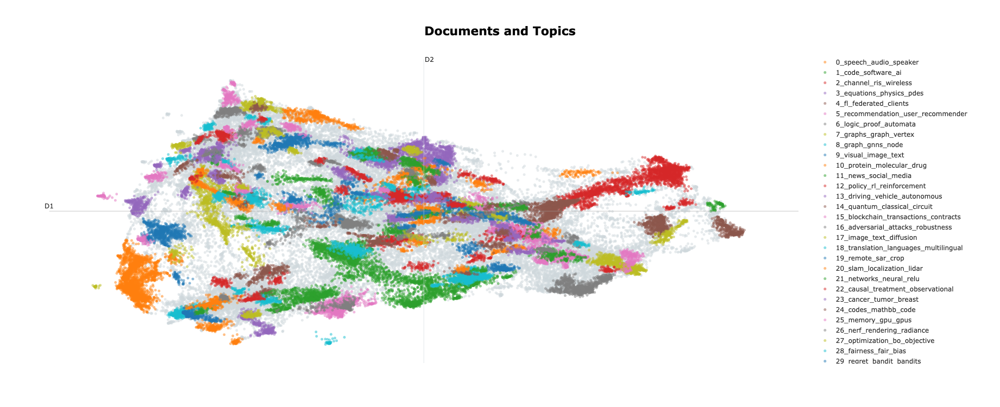

In [39]:
fig

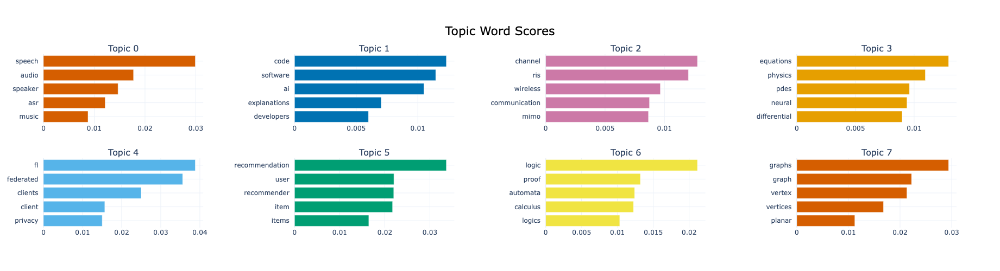

In [40]:
topic_model.visualize_barchart()

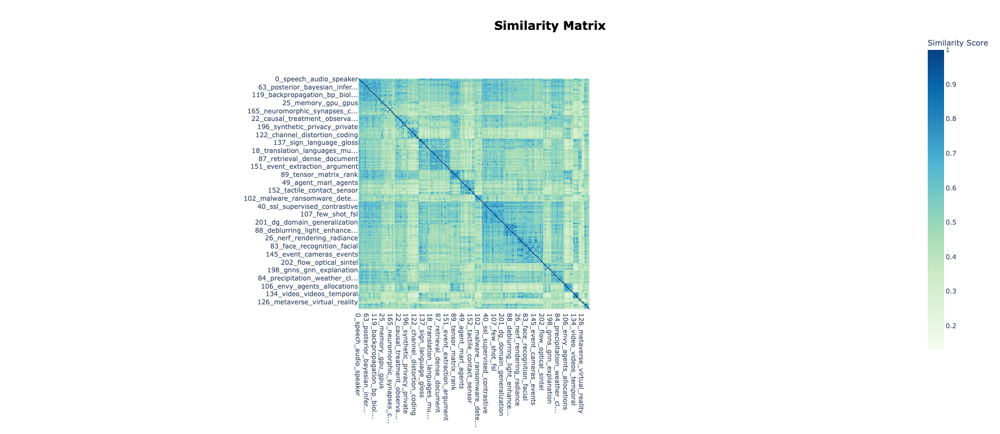

In [41]:
topic_model.visualize_heatmap(n_clusters=20)

## Naming Topics Using LLMs

In [46]:
from openai import OpenAI
from bertopic.representation import OpenAI as BERTopicOpenAI

In [47]:
client = OpenAI(
    base_url="http://boris:38888/v1",
    api_key="EMPTY",  # SGLang doesn't require one unless you configured --api-key
)

In [48]:
print(client.models.list())

SyncPage[Model](data=[Model(id='qwen3.8-27b-nvfp4-control', created=1789335604, object='model', owned_by='sglang', root='qwen3.8-27b-nvfp4-control', parent=None, max_model_len=262144)], object='list')


In [60]:
representation_model = BERTopicOpenAI(
    client,
    model="qwen3.8-27b-nvfp4-control",
    nr_docs=4,
    doc_length=100,
    tokenizer="whitespace",
    generator_kwargs={
        "extra_body": {
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    },
)

In [61]:
topic_model.update_topics(abstracts, representation_model=representation_model)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 204/204 [00:46<00:00,  4.39it/s]


In [62]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,46617,-1_Advancements in machine learning,[Advancements in machine learning],[Pretrained language models based on the trans...
1,0,3322,0_Speech processing models,[Speech processing models],"[In recent years, the joint training of speech..."
2,1,3178,1_AI software research,[AI software research],[The shift from symbolic AI systems to black-b...
3,2,2725,2_Intelligent wireless networks,[Intelligent wireless networks],[The various requirements in terms of data rat...
4,3,1409,3_Physics-informed neural networks,[Physics-informed neural networks],[Physics-informed neural networks (PINNs) have...
...,...,...,...,...,...
199,198,52,198_GNN explainability,[GNN explainability],[Graph Neural Networks (GNNs) are widely adopt...
200,199,51,199_Aspect-based sentiment analysis,[Aspect-based sentiment analysis],[Aspect-based sentiment analysis (ABSA) aims a...
201,200,50,200_Opinion dynamics,[Opinion dynamics],[Opinion spreading in a society decides the fa...
202,201,50,201_Domain generalization,[Domain generalization],[Domain generalization (DG) focuses on transfe...


In [63]:
topic_model.get_topic_info()[["Topic", "Representation"]]

,Topic,Representation
0,-1,[Advancements in machine learning]
1,0,[Speech processing models]
2,1,[AI software research]
3,2,[Intelligent wireless networks]
4,3,[Physics-informed neural networks]
...,...,...
199,198,[GNN explainability]
200,199,[Aspect-based sentiment analysis]
201,200,[Opinion dynamics]
202,201,[Domain generalization]
